## ChocoScope: Retail Intelligence & Revenue Forecasting for a Global Chocolate Brand

In [1]:
# =========================
# 1. LIBRARY IMPORTS
# =========================

import warnings
warnings.filterwarnings("ignore")

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistics
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Notebook settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

In [16]:
!kaggle datasets download -d ssssws/chocolate-sales-dataset-2023-2024

Dataset URL: https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024
License(s): apache-2.0
100% 23.3M/23.3M [00:00<00:00, 176MB/s]



In [18]:
import zipfile
import os

zip_file = "chocolate-sales-dataset-2023-2024.zip"  # The downloaded zip
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(".")  # Extract to current directory

print("Files in current directory:", os.listdir("."))

Files in current directory: ['.config', '.ipynb_checkpoints', 'chocolate-sales-dataset-2023-2024.zip', 'sales.csv', 'calendar.csv', 'customers.csv', 'products.csv', 'stores.csv', 'sample_data']


In [21]:
# =========================
# 2. DATASET LOADING
# =========================

sales = pd.read_csv("sales.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
stores = pd.read_csv("stores.csv")
calendar = pd.read_csv("calendar.csv")

print("Sales shape:", sales.shape)
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Stores shape:", stores.shape)
print("Calendar shape:", calendar.shape)

Sales shape: (1000000, 11)
Customers shape: (50000, 5)
Products shape: (200, 6)
Stores shape: (100, 5)
Calendar shape: (731, 6)


In [22]:
# Preview datasets
display(sales.head())
display(customers.head())
display(products.head())
display(stores.head())
display(calendar.head())

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [ ]:
# =========================
# 3. INITIAL DATA INSPECTION
# =========================

datasets = {
    "sales": sales,
    "customers": customers,
    "products": products,
    "stores": stores,
    "calendar": calendar
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"{name.upper()} INFO")
    print(f"{'='*50}")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())
    print("\nSummary Statistics:")
    display(df.describe(include="all").T)


SALES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB
None

Missing Values:
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64

Duplicate Rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1000000,1000000,0RD00000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,1000000,731,2023-06-10,1463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,1000000,202,P0021,5141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,1000000,100,S013,10194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,1000000,50000,C044952,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,1000000.0,NaN,NaN,NaN,2.999589,1.413621,1.0,2.0,3.0,4.0,5.0
unit_price,1000000.0,NaN,NaN,NaN,9.002449,3.462902,3.0,6.0,9.01,12.0,15.0
discount,1000000.0,NaN,NaN,NaN,0.056248,0.076809,0.0,0.0,0.0,0.15,0.2
revenue,1000000.0,NaN,NaN,NaN,25.486129,16.367864,2.4,12.16,21.92,35.88,75.0
cost,1000000.0,NaN,NaN,NaN,15.291554,9.972706,1.2,7.24,13.03,21.41,52.43



CUSTOMERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     50000 non-null  object
 1   age             50000 non-null  int64 
 2   gender          50000 non-null  object
 3   loyalty_member  50000 non-null  int64 
 4   join_date       50000 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB
None

Missing Values:
customer_id       0
age               0
gender            0
loyalty_member    0
join_date         0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,50000,50000,C000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,50000.0,NaN,NaN,NaN,44.0261,15.328333,18.0,31.0,44.0,57.0,70.0
gender,50000,2,Male,25242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loyalty_member,50000.0,NaN,NaN,NaN,0.50208,0.500001,0.0,0.0,1.0,1.0,1.0
join_date,50000,1827,2023-09-06,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN



PRODUCTS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB
None

Missing Values:
product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,200,200,P0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,200,25,Dark Chocolate 50%,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,200,6,Cadbury,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,200,5,Praline,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cocoa_percent,200.0,NaN,NaN,NaN,69.15,14.623499,50.0,50.0,70.0,80.0,90.0
weight_g,200.0,NaN,NaN,NaN,107.5,50.898954,50.0,80.0,100.0,120.0,200.0



STORES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    100 non-null    object
 1   store_name  100 non-null    object
 2   city        100 non-null    object
 3   country     100 non-null    object
 4   store_type  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB
None

Missing Values:
store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,count,unique,top,freq
store_id,100,100,S001,1
store_name,100,100,Chocolate Store 1,1
city,100,7,Toronto,18
country,100,6,Canada,20
store_type,100,4,Airport,30



CALENDAR INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB
None

Missing Values:
date           0
year           0
month          0
day            0
week           0
day_of_week    0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,731,731,2023-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,731.0,NaN,NaN,NaN,2023.500684,0.500342,2023.0,2023.0,2024.0,2024.0,2024.0
month,731.0,NaN,NaN,NaN,6.519836,3.451913,1.0,4.0,7.0,10.0,12.0
day,731.0,NaN,NaN,NaN,15.738714,8.809949,1.0,8.0,16.0,23.0,31.0
week,731.0,NaN,NaN,NaN,26.465116,15.076602,1.0,13.0,26.0,39.5,52.0
day_of_week,731.0,NaN,NaN,NaN,2.997264,2.004787,0.0,1.0,3.0,5.0,6.0


In [ ]:
# =========================
# 4. DATA CLEANING
# =========================

# Convert date columns
sales["order_date"] = pd.to_datetime(sales["order_date"], errors="coerce")
customers["join_date"] = pd.to_datetime(customers["join_date"], errors="coerce")
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")

# Standardize string columns
for df in [customers, products, stores]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

# Create profit column if not already present
if "profit" not in sales.columns:
    sales["profit"] = sales["revenue"] - sales["cost"]

# Check for invalid numeric values
numeric_cols = ["quantity", "unit_price", "discount", "revenue", "cost", "profit"]
for col in numeric_cols:
    if col in sales.columns:
        print(f"{col}: negative values =", (sales[col] < 0).sum())

# Remove impossible rows (if any)
sales = sales[sales["quantity"] > 0].copy()
sales = sales[sales["unit_price"] >= 0].copy()

# Missing values overview
print("Missing values in products:")
print(products.isnull().sum())

print("Missing values in sales:")
print(sales.isnull().sum())

quantity: negative values = 0
unit_price: negative values = 0
discount: negative values = 0
revenue: negative values = 0
cost: negative values = 0
profit: negative values = 0
Missing values in products:
product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64
Missing values in sales:
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64


In [ ]:
# Investigate product IDs in sales not found in products
missing_product_ids = set(sales["product_id"].unique()) - set(products["product_id"].unique())
print("Product IDs in sales but missing from products:", missing_product_ids)
print("Count missing product IDs:", len(missing_product_ids))

Product IDs in sales but missing from products: {'P0000', 'P0201'}
Count missing product IDs: 2


In [ ]:
# =========================
# 5. DATA MERGING
# =========================

df = sales.merge(products, on="product_id", how="left") \
          .merge(stores, on="store_id", how="left") \
          .merge(customers, on="customer_id", how="left")

# Merge with calendar for richer date features
df = df.merge(calendar, left_on="order_date", right_on="date", how="left")

print("Merged dataset shape:", df.shape)
display(df.head())

Merged dataset shape: (1000000, 30)


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,New York,Australia,Retail,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,London,UK,Airport,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,Toronto,USA,Retail,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,London,Canada,Online,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1


In [ ]:
# =========================
# 6. FEATURE ENGINEERING
# =========================

# Time-based features
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.day_name()
df["order_quarter"] = df["order_date"].dt.quarter
df["is_weekend"] = df["order_date"].dt.weekday >= 5

# Customer features
df["customer_tenure_days"] = (df["order_date"] - df["join_date"]).dt.days
df["customer_tenure_days"] = df["customer_tenure_days"].clip(lower=0)

# Product-level pricing features
df["discounted_unit_price"] = df["unit_price"] * (1 - df["discount"])
df["revenue_per_unit"] = df["revenue"] / df["quantity"]
df["profit_margin"] = np.where(df["revenue"] > 0, df["profit"] / df["revenue"], 0)

# Cocoa percent cleaning
if "cocoa_percent" in df.columns:
    df["cocoa_percent_clean"] = (
        df["cocoa_percent"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("nan", np.nan)
    )
    df["cocoa_percent_clean"] = pd.to_numeric(df["cocoa_percent_clean"], errors="coerce")

# Basket/order-level features
order_summary = df.groupby("order_id").agg(
    order_total_revenue=("revenue", "sum"),
    order_total_profit=("profit", "sum"),
    order_total_quantity=("quantity", "sum"),
    unique_products_in_order=("product_id", "nunique")
).reset_index()

df = df.merge(order_summary, on="order_id", how="left")

display(df.head())

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week,order_year,order_month,order_day,order_weekday,order_quarter,is_weekend,customer_tenure_days,discounted_unit_price,revenue_per_unit,profit_margin,cocoa_percent_clean,order_total_revenue,order_total_profit,order_total_quantity,unique_products_in_order
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5,2023,1,7,Saturday,1,True,416,12.2655,12.266,0.302625,70.0,61.33,18.56,5,1
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,New York,Australia,Retail,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6,2023,10,22,Sunday,4,True,111,12.0100,12.010,0.470996,60.0,36.03,16.97,3,1
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,London,UK,Airport,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6,2023,5,7,Sunday,2,True,0,10.0200,10.020,0.486527,90.0,20.04,9.75,2,1
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,Toronto,USA,Retail,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6,2024,6,23,Sunday,2,True,390,13.1940,13.195,0.380447,60.0,26.39,10.04,2,1
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,London,Canada,Online,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1,2024,9,24,Tuesday,3,False,1131,12.3400,12.340,0.356564,90.0,12.34,4.40,1,1


In [ ]:
# =========================
# 7.1 OVERALL KPIs
# =========================

total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
avg_order_value = df.groupby("order_id")["revenue"].sum().mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Total Revenue: $25,486,128.86
Total Profit: $10,194,564.63
Total Orders: 1,000,000
Total Customers: 50,000
Average Order Value: $25.49


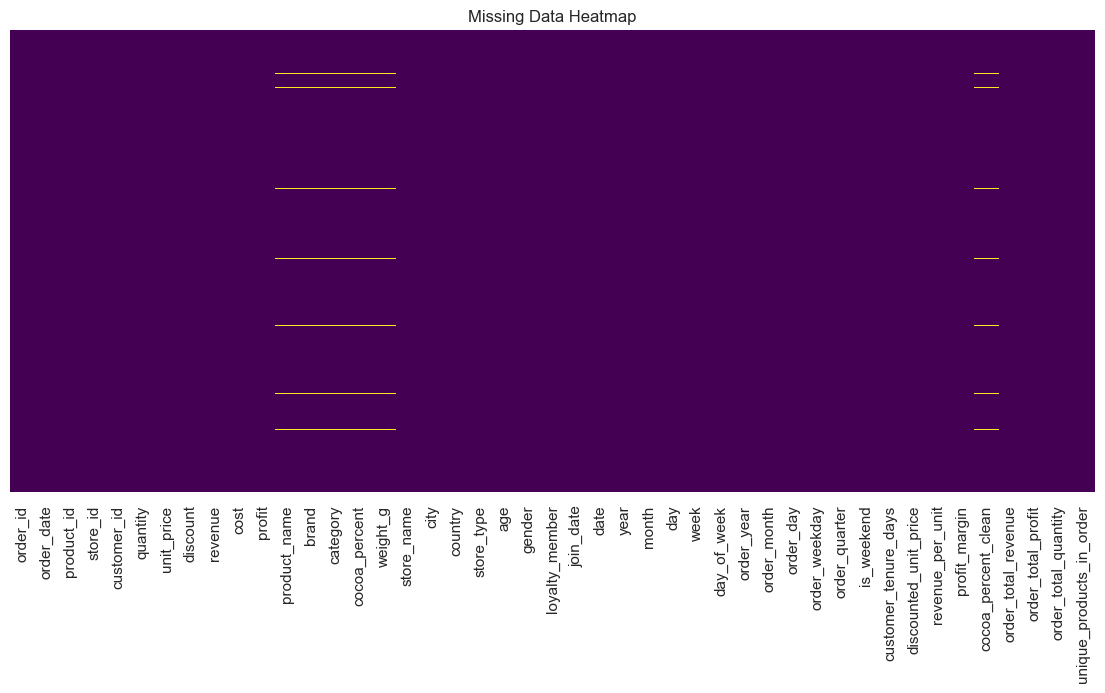

In [ ]:
# =========================
# 7.2 MISSING DATA
# =========================

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

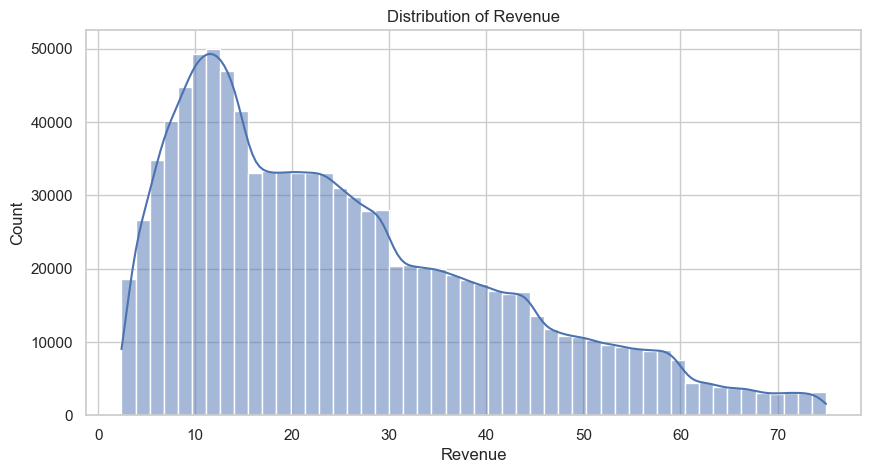

In [ ]:
# =========================
# 7.3 REVENUE DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))
sns.histplot(df["revenue"], bins=50, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.show()

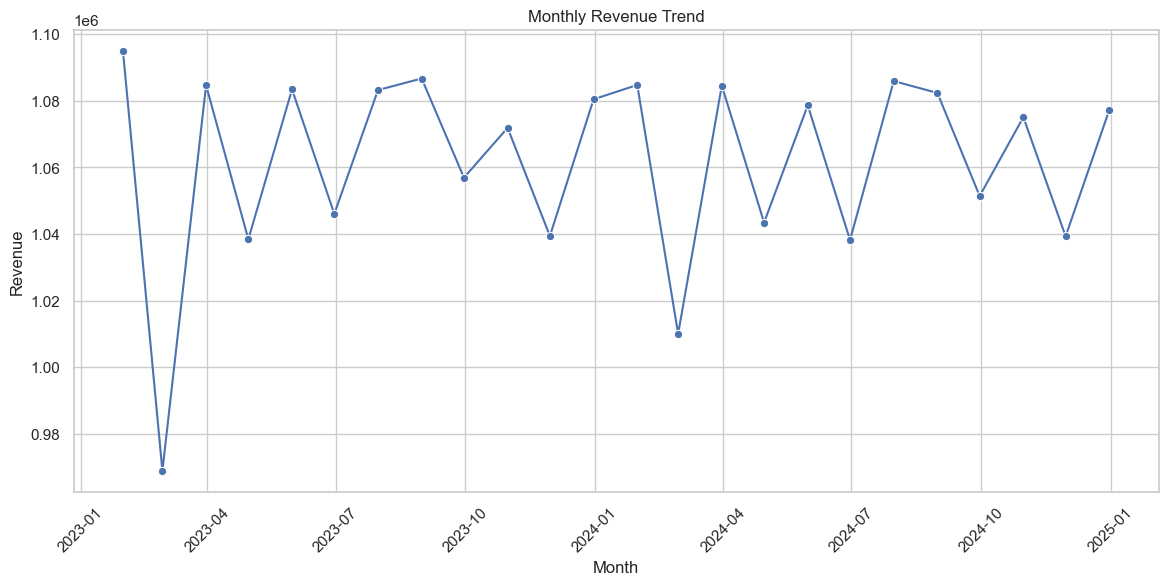

In [ ]:
# =========================
# 7.4 MONTHLY REVENUE TREND
# =========================

monthly_revenue = df.groupby(pd.Grouper(key="order_date", freq="M"))["revenue"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x="order_date", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Interactive Plotly version
fig = px.line(monthly_revenue, x="order_date", y="revenue",
              title="Monthly Revenue Trend (Interactive)", markers=True)
fig.show()

,total_revenue,total_profit,total_quantity
category,,,
Praline,6665641.32,2665242.79,784435
White,6070172.20,2428117.37,714967
Dark,5298123.27,2120672.08,623247
Truffle,3924343.24,1569202.54,462202
Milk,3280368.19,1312407.13,385619


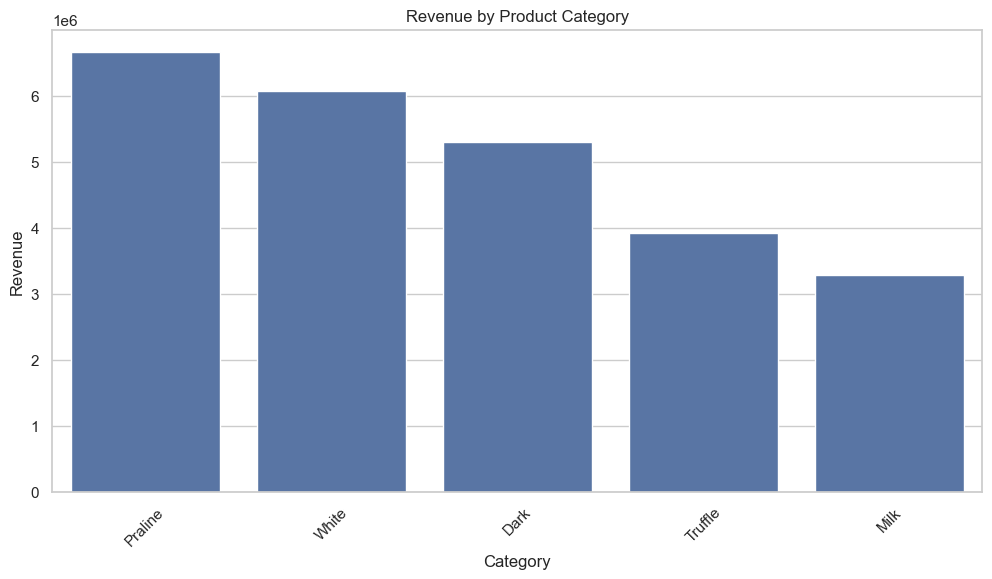

In [ ]:
# =========================
# 7.5 CATEGORY PERFORMANCE
# =========================

category_perf = df.groupby("category").agg(
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).sort_values("total_revenue", ascending=False)

display(category_perf)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_perf.index, y=category_perf["total_revenue"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

,store_name,country,store_type,total_revenue,total_profit,total_orders
0,Chocolate Store 74,USA,Online,261393.77,104809.57,10154
1,Chocolate Store 33,Australia,Retail,260672.37,104519.64,10186
2,Chocolate Store 50,Canada,Airport,259526.62,104000.38,10110
3,Chocolate Store 27,Germany,Airport,259006.23,103834.60,10163
4,Chocolate Store 22,USA,Retail,258914.68,103699.15,10136
5,Chocolate Store 98,Australia,Online,259055.13,103663.07,10130
6,Chocolate Store 85,USA,Online,259512.15,103621.20,10072
7,Chocolate Store 96,UK,Mall,257931.98,103398.35,9998
8,Chocolate Store 59,Germany,Airport,258014.72,103383.67,10123
9,Chocolate Store 90,France,Online,258135.85,103360.35,10104


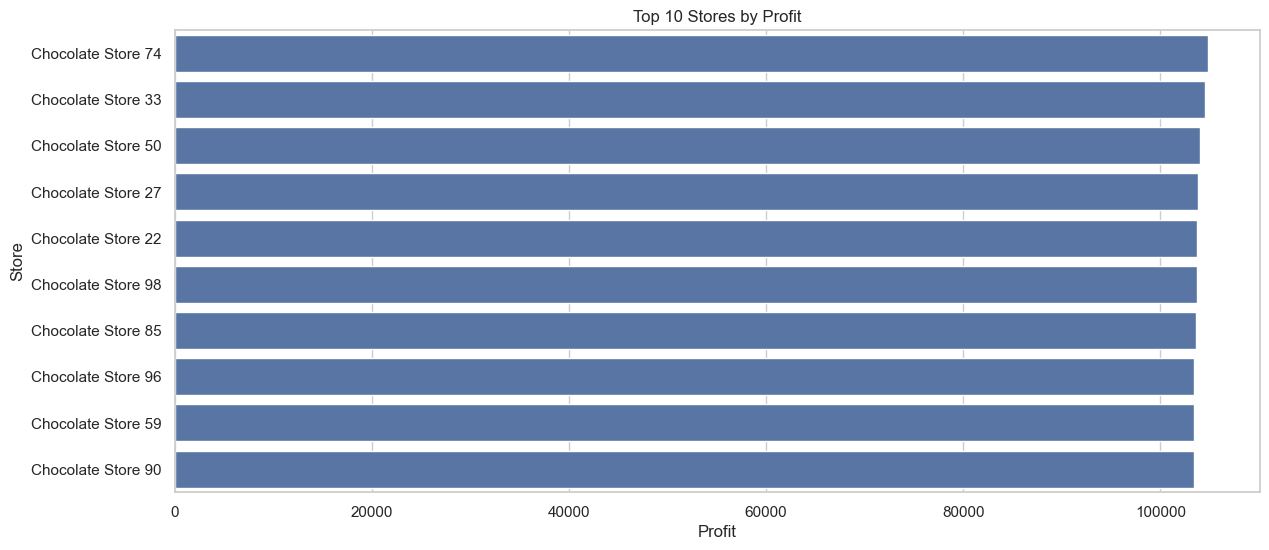

In [ ]:
# =========================
# 7.6 STORE PERFORMANCE
# =========================

store_perf = df.groupby(["store_name", "country", "store_type"]).agg(
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique")
).sort_values("total_profit", ascending=False).reset_index()

display(store_perf.head(10))

top_stores = store_perf.head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_stores, x="total_profit", y="store_name")
plt.title("Top 10 Stores by Profit")
plt.xlabel("Profit")
plt.ylabel("Store")
plt.show()

In [ ]:
# =========================
# 7.7 CUSTOMER SEGMENTATION
# =========================

customer_summary = df.groupby("customer_id").agg(
    total_spent=("revenue", "sum"),
    total_orders=("order_id", "nunique"),
    total_profit=("profit", "sum"),
    avg_discount=("discount", "mean"),
    age=("age", "first"),
    loyalty_member=("loyalty_member", "first"),
    gender=("gender", "first")
).reset_index()

customer_summary["segment"] = pd.qcut(
    customer_summary["total_spent"],
    q=4,
    labels=["Bronze", "Silver", "Gold", "Platinum"]
)

display(customer_summary.head())

,customer_id,total_spent,total_orders,total_profit,avg_discount,age,loyalty_member,gender,segment
0,C000001,481.16,25,197.08,0.078000,40,1,Male,Silver
1,C000002,586.11,24,253.00,0.060417,47,0,Male,Gold
2,C000003,678.37,24,248.14,0.047917,58,1,Female,Platinum
3,C000004,533.11,18,216.35,0.019444,25,0,Female,Gold
4,C000005,811.12,32,337.23,0.057813,43,0,Male,Platinum


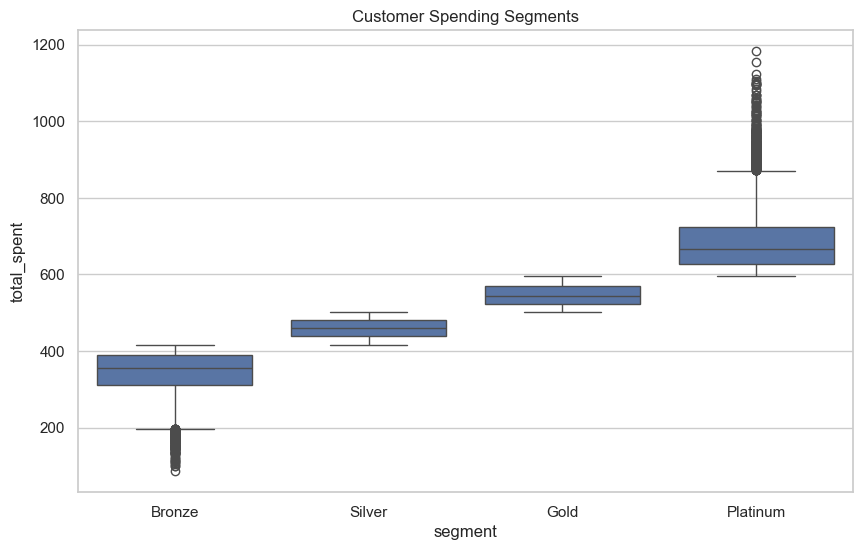

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customer_summary, x="segment", y="total_spent")
plt.title("Customer Spending Segments")
plt.show()

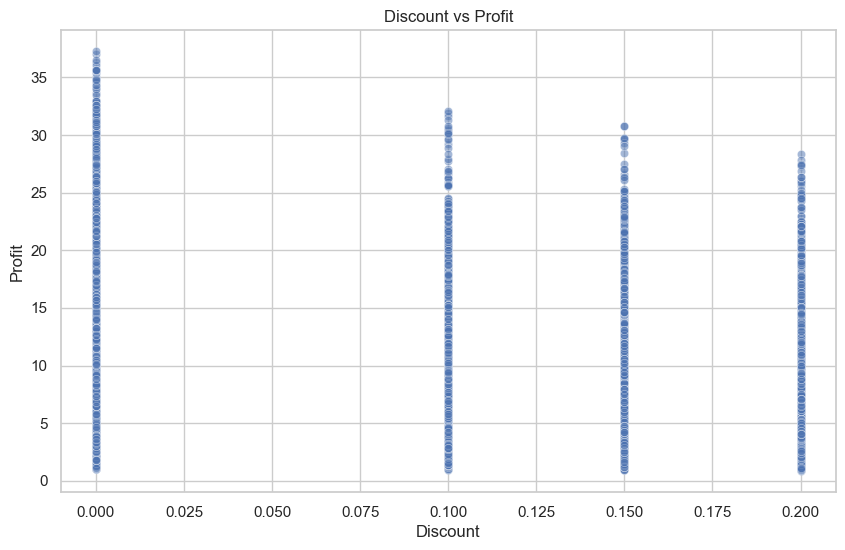

In [ ]:
# =========================
# 7.8 DISCOUNT VS PROFITABILITY
# =========================

sample_df = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="discount", y="profit", alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

,discount,profit,revenue,quantity
discount,1.000000,-0.123258,-0.127252,-0.000147
profit,-0.123258,1.000000,0.966183,0.709027
revenue,-0.127252,0.966183,1.000000,0.733962
quantity,-0.000147,0.709027,0.733962,1.000000


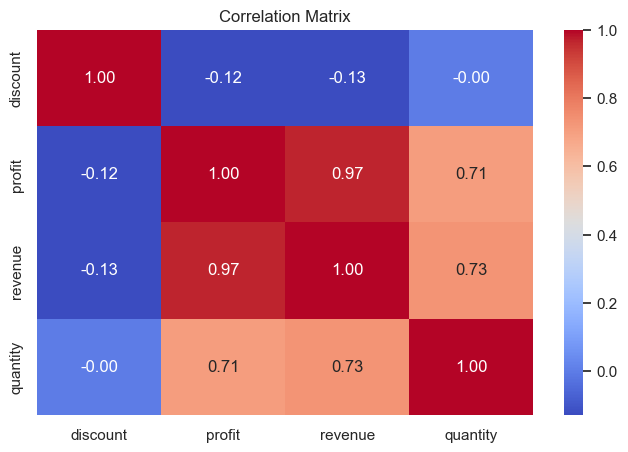

In [ ]:
# Correlation between discount and profit
corr = df[["discount", "profit", "revenue", "quantity"]].corr()
display(corr)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# =========================
# 8. STATISTICAL ANALYSIS
# =========================

# Compare revenue between loyalty and non-loyalty customers
loyal = df[df["loyalty_member"] == "Yes"]["revenue"].dropna()
non_loyal = df[df["loyalty_member"] == "No"]["revenue"].dropna()

t_stat, p_value = stats.ttest_ind(loyal, non_loyal, equal_var=False)
print("T-test: Loyalty vs Non-Loyalty Revenue")
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-test: Loyalty vs Non-Loyalty Revenue
T-statistic: nan
P-value: nan


In [ ]:
# OLS regression: effect of discount and quantity on revenue
reg_df = df[["revenue", "discount", "quantity"]].dropna().copy()
model = smf.ols("revenue ~ discount + quantity", data=reg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                 6.233e+05
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:57:28   Log-Likelihood:            -3.8096e+06
No. Observations:             1000000   AIC:                         7.619e+06
Df Residuals:                  999997   BIC:                         7.619e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5193      0.027     56.614      0.0

In [ ]:
# =========================
# 9. MODELING DATA PREP
# =========================

model_df = df.copy()

# Drop rows with missing target
model_df = model_df.dropna(subset=["revenue"])

# Feature selection
features = [
    "quantity",
    "unit_price",
    "discount",
    "cost",
    "age",
    "loyalty_member",
    "gender",
    "customer_tenure_days",
    "brand",
    "category",
    "cocoa_percent_clean",
    "weight_g",
    "country",
    "store_type",
    "order_month",
    "order_quarter",
    "day_of_week"
]

target = "revenue"

# Keep only available columns
features = [col for col in features if col in model_df.columns]

X = model_df[features]
y = model_df[target]

print("Feature columns:", features)
print("X shape:", X.shape)

Feature columns: ['quantity', 'unit_price', 'discount', 'cost', 'age', 'loyalty_member', 'gender', 'customer_tenure_days', 'brand', 'category', 'cocoa_percent_clean', 'weight_g', 'country', 'store_type', 'order_month', 'order_quarter', 'day_of_week']
X shape: (1000000, 17)


In [ ]:
# =========================
# 10. PREPROCESSING PIPELINE
# =========================

numeric_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Numeric features: ['quantity', 'unit_price', 'discount', 'cost', 'age', 'loyalty_member', 'customer_tenure_days', 'cocoa_percent_clean', 'weight_g', 'day_of_week']
Categorical features: ['gender', 'brand', 'category', 'country', 'store_type']


In [ ]:
# =========================
# 11. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800000, 17)
Test shape: (200000, 17)


In [ ]:
# =========================
# 12. MODEL TRAINING
# =========================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{model_name} complete.")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)

Linear Regression complete.
Random Forest complete.
Gradient Boosting complete.


,Model,MAE,RMSE,R2
1,Random Forest,0.001679,0.006518,1.000000
2,Gradient Boosting,1.436527,1.823479,0.987593
0,Linear Regression,1.938098,2.498422,0.976708


In [ ]:
# =========================
# 13. BEST MODEL EVALUATION
# =========================

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Best Model: Random Forest
MAE: 0.0016793770000180556
RMSE: 0.006517816743358018
R²: 0.9999998414827376


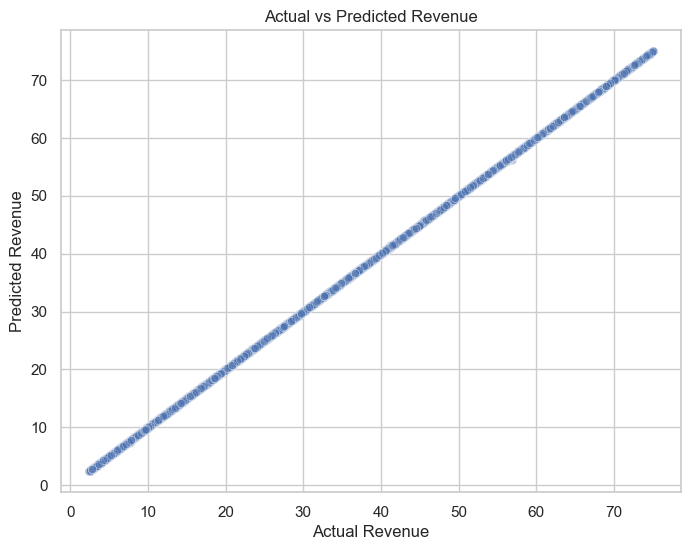

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

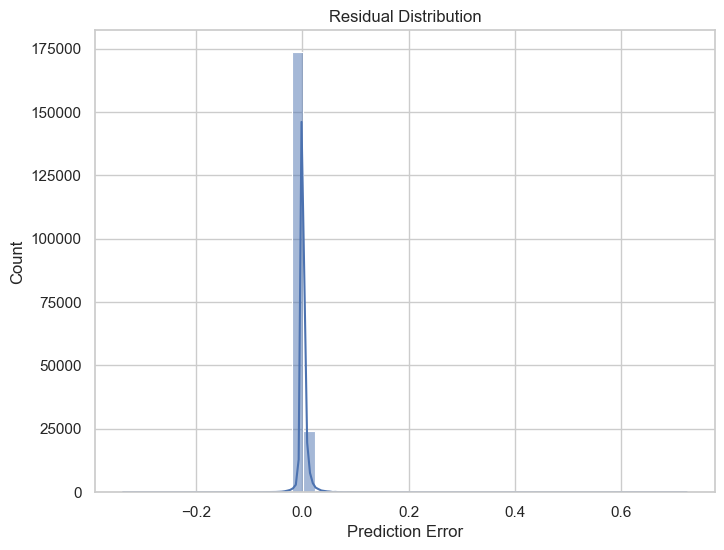

In [ ]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

,feature,importance
3,cost,9.684022e-01
1,unit_price,1.677590e-02
2,discount,7.970510e-03
0,quantity,6.851012e-03
4,age,4.980181e-08
6,customer_tenure_days,4.727777e-08
9,day_of_week,3.014728e-08
7,cocoa_percent_clean,2.605850e-08
8,weight_g,2.416074e-08
5,loyalty_member,1.053904e-08


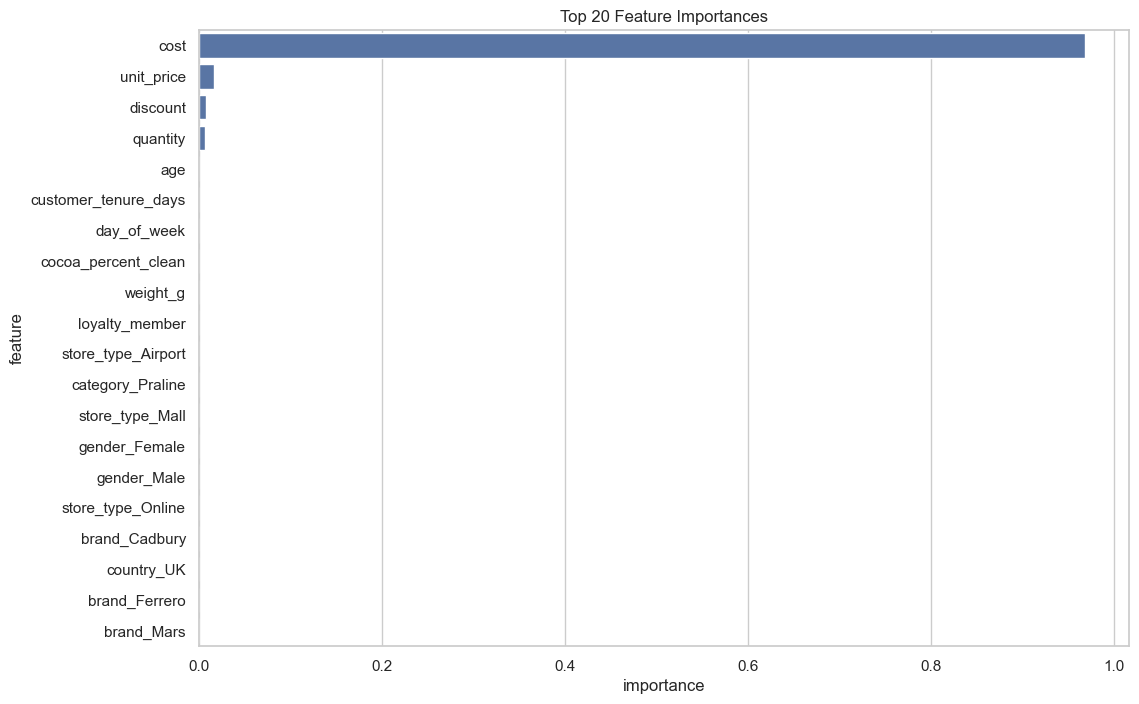

In [ ]:
# =========================
# 14. FEATURE IMPORTANCE
# =========================

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    transformed_feature_names = []

    # numeric feature names
    transformed_feature_names.extend(numeric_features)

    # categorical one-hot feature names
    ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    transformed_feature_names.extend(cat_feature_names)

    importances = best_pipeline.named_steps["model"].feature_importances_

    feature_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(20)

    display(feature_importance_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance_df, x="importance", y="feature")
    plt.title("Top 20 Feature Importances")
    plt.show()

In [ ]:
# =========================
# 15. SAVE OUTPUTS
# =========================

df.to_csv("merged_retail_data.csv", index=False)
model_df.to_csv("model_ready_data.csv", index=False)

print("Processed files saved successfully.")

Processed files saved successfully.


In [ ]:
# =========================
# 16. QUICK SUMMARY TABLES
# =========================

top_categories = df.groupby("category")["revenue"].sum().sort_values(ascending=False).head(10)
top_countries = df.groupby("country")["revenue"].sum().sort_values(ascending=False)
top_customers = customer_summary.sort_values("total_spent", ascending=False).head(10)

display(top_categories)
display(top_countries)
display(top_customers)

category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64

country
Canada       5085319.05
UK           4823617.98
USA          4341494.26
France       4339730.90
Australia    3834803.40
Germany      3061163.27
Name: revenue, dtype: float64

,customer_id,total_spent,total_orders,total_profit,avg_discount,age,loyalty_member,gender,segment
33308,C033309,1183.16,39,467.38,0.044872,46,1,Male,Platinum
9918,C009919,1153.66,38,451.10,0.057895,32,1,Male,Platinum
44801,C044802,1123.37,34,437.72,0.035294,53,1,Male,Platinum
24447,C024448,1111.54,32,426.64,0.076563,24,0,Male,Platinum
26506,C026507,1104.10,37,445.33,0.044595,40,1,Female,Platinum
20497,C020498,1100.16,35,419.45,0.054286,33,1,Male,Platinum
28532,C028533,1099.16,33,440.62,0.046970,65,0,Female,Platinum
32745,C032746,1096.58,35,448.42,0.050000,31,0,Female,Platinum
19741,C019742,1096.15,34,426.61,0.036765,21,1,Male,Platinum
40735,C040736,1095.84,33,455.15,0.039394,53,1,Female,Platinum


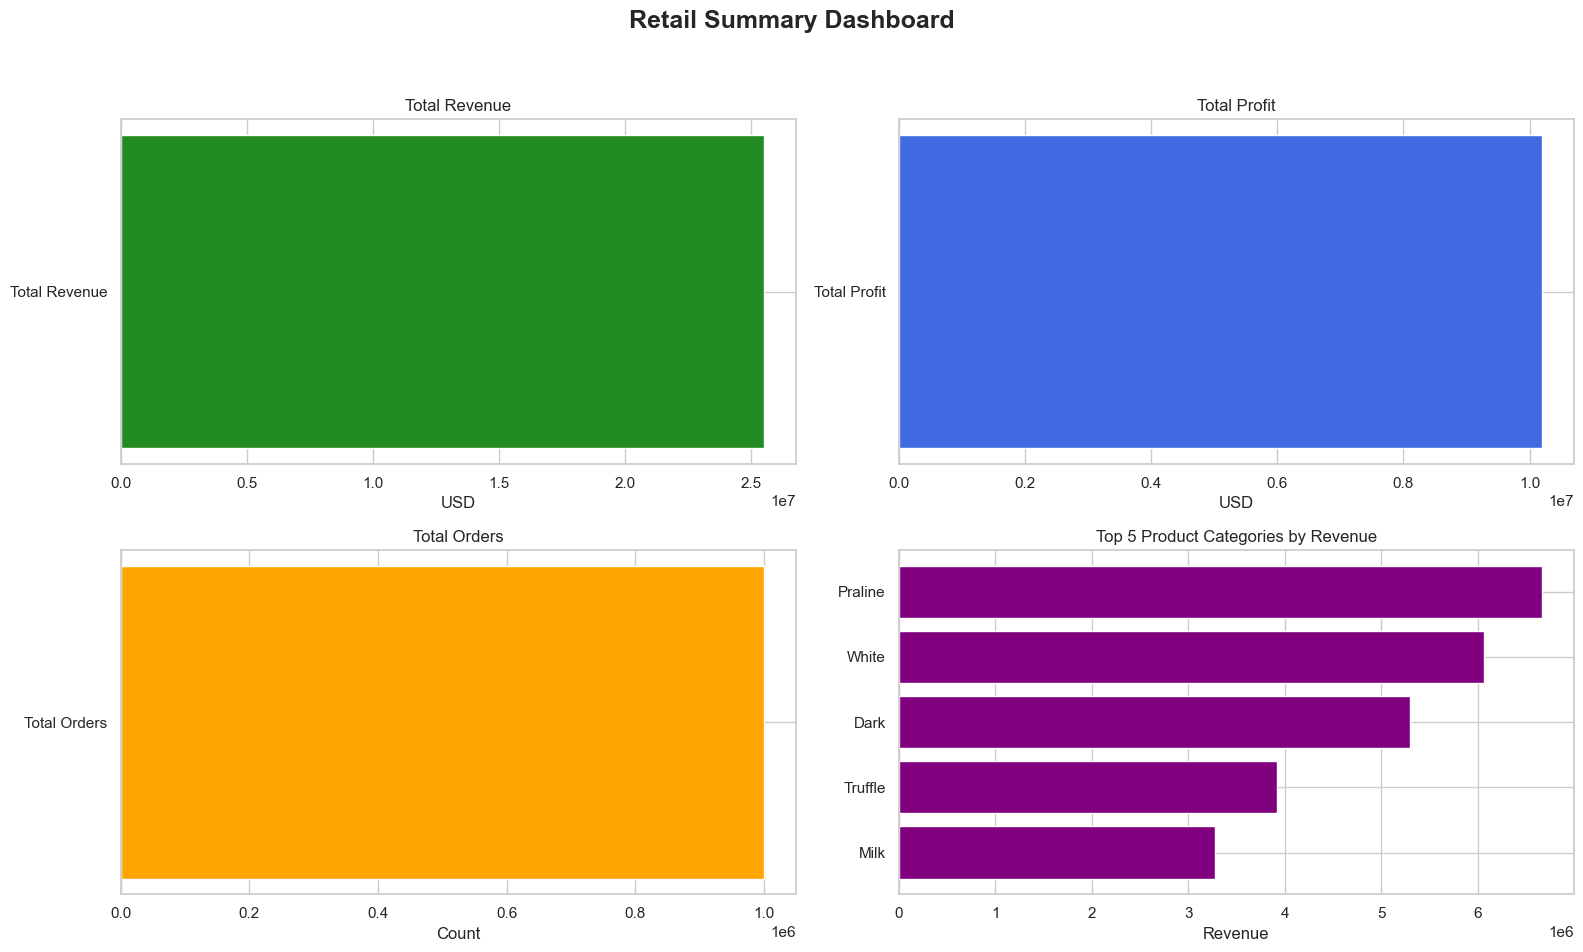

In [ ]:
# =========================
# FINAL SUMMARY GRAPH
# =========================

# Aggregate key metrics
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

# Top 5 categories by revenue
top_categories = df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(5)

# Create a summary figure
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Retail Summary Dashboard', fontsize=18, weight='bold')

# Total Revenue
ax[0,0].barh(['Total Revenue'], [total_revenue], color='forestgreen')
ax[0,0].set_xlabel('USD')
ax[0,0].set_title('Total Revenue')

# Total Profit
ax[0,1].barh(['Total Profit'], [total_profit], color='royalblue')
ax[0,1].set_xlabel('USD')
ax[0,1].set_title('Total Profit')

# Total Orders
ax[1,0].barh(['Total Orders'], [total_orders], color='orange')
ax[1,0].set_xlabel('Count')
ax[1,0].set_title('Total Orders')

# Top Categories Revenue
ax[1,1].barh(top_categories.index[::-1], top_categories.values[::-1], color='purple')
ax[1,1].set_xlabel('Revenue')
ax[1,1].set_title('Top 5 Product Categories by Revenue')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()